<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/Market-Regime-Visualization/Market_Regime_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import norm

import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
tickers = ["^GSPC"]

data = yf.download(tickers, start = '2023-01-01', end = '2026-01-01')['Close']
data.head()

/tmp/ipython-input-1430616913.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = '2023-01-01', end = '2026-01-01')['Close']
[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2023-01-03,3824.139893
2023-01-04,3852.969971
2023-01-05,3808.100098
2023-01-06,3895.080078
2023-01-09,3892.090088


In [ ]:
returns = data.pct_change().dropna()
returns.head()

Ticker,^GSPC
Date,
2023-01-04,0.007539
2023-01-05,-0.011646
2023-01-06,0.022841
2023-01-09,-0.000768
2023-01-10,0.006978


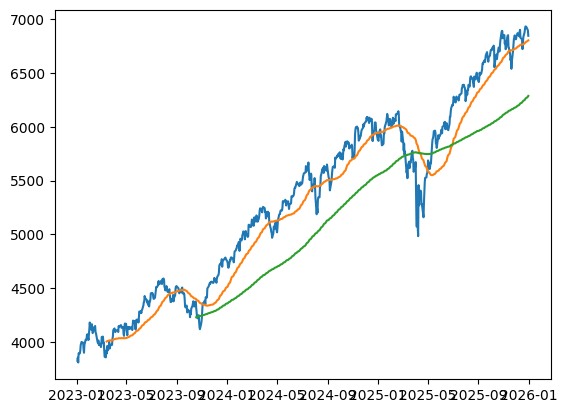

In [ ]:
sma50 = data.rolling(50).mean()
sma200 = data.rolling(200).mean()

plt.plot(data.index, data)
plt.plot(sma50.index, sma50)
plt.plot(sma200)
plt.show()

We can define a Bull Market as 1 of the following:
1. Price > SMA200 -> Bull, Price < SMA200 -> Bear.
2. Slope of SMA50 > 0.1% -> Bull, < -0.1% -> Bear.

In [ ]:
# For Option 2
sma_slope = sma50.pct_change() * 100
sma_slope.tail()

Ticker,^GSPC
Date,
2025-12-24,0.084889
2025-12-26,0.076310
2025-12-29,0.081492
2025-12-30,0.068346
2025-12-31,0.032460


In [ ]:
data['sma50'] = sma50
data['sma200'] = sma200
data['sma_slope'] = sma_slope
threshold = 0.001

def get_regime(row):
  if(row['^GSPC'] > row['sma200'] and row['sma_slope'] > threshold):
    return "Bull"
  elif(row['^GSPC'] < row['sma200'] and row['sma_slope'] < threshold*-1):
    return "Bear"
  else:
    return "Sideways"
data['regime'] = data.apply(get_regime, axis = 1)
data.tail()

Ticker,^GSPC,sma50,sma200,sma_slope,regime
Date,,,,,
2025-12-24,6932.049805,6784.985977,6260.738538,0.084889,Bull
2025-12-26,6929.939941,6790.163574,6267.391738,0.076310,Bull
2025-12-29,6905.740234,6795.696982,6274.312839,0.081492,Bull
2025-12-30,6896.240234,6800.341592,6280.599341,0.068346,Bull
2025-12-31,6845.500000,6802.548994,6286.451240,0.032460,Bull


In [ ]:
data['regime'].value_counts()

,count
regime,
Bull,470
Sideways,232
Bear,50


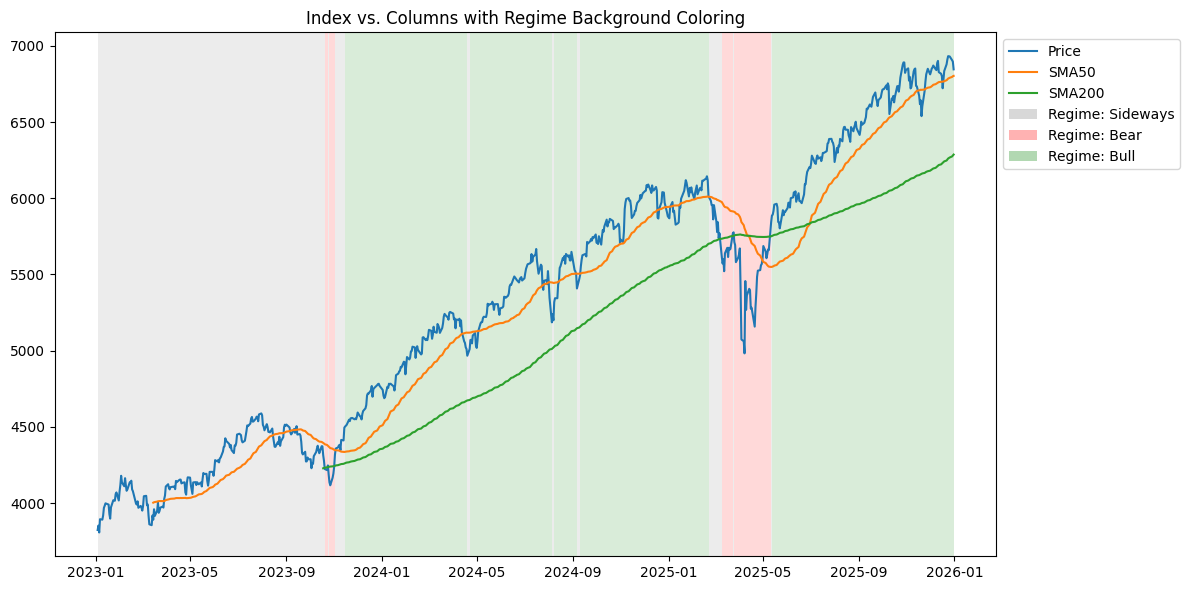

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Assuming df has 4 columns: 'A', 'B', 'C' (numeric) and 'Regime' (categorical)
# Mapping of regime values to specific colors
colors_map = {'Sideways': 'gray', 'Bear': 'red', 'Bull': 'green'}

fig, ax = plt.subplots(figsize=(12, 6))

# 1. Plot the numeric columns against the index
ax.plot(data.index, data['^GSPC'], label='Price', linewidth=1.5)
ax.plot(data.index, data['sma50'], label='SMA50', linewidth=1.5)
ax.plot(data.index, data['sma200'], label='SMA200', linewidth=1.5)

# 2. Logic to color the background regions
# We detect where the 'Regime' column value changes to define the blocks
start_idx = data.index[0]
current_val = data['regime'].iloc[0]

for i in range(1, len(data)):
    if data['regime'].iloc[i] != current_val:
        # Draw the background color for the segment just finished
        ax.axvspan(start_idx, data.index[i], facecolor=colors_map[current_val], alpha=0.15)

        # Reset for the next segment
        start_idx = data.index[i]
        current_val = data['regime'].iloc[i]

# Add the final span for the last segment of the data
ax.axvspan(start_idx, data.index[-1], facecolor=colors_map[current_val], alpha=0.15)

# 3. Create a custom legend for the regions
# Standard legends only show the lines; we add Patches for the colors
legend_elements = [
    Patch(facecolor='gray', alpha=0.3, label='Regime: Sideways'),
    Patch(facecolor='red', alpha=0.3, label='Regime: Bear'),
    Patch(facecolor='green', alpha=0.3, label='Regime: Bull')
]
# Combine with standard line labels
line_labels = ax.get_legend_handles_labels()[0]
ax.legend(handles=line_labels + legend_elements, loc='upper left', bbox_to_anchor=(1, 1))

plt.title("Index vs. Columns with Regime Background Coloring")
plt.tight_layout()
plt.show()

S&P500 was Bullish for the majority of the time period looked at.